Papadopoulos Ioannis-Rafail
AEM: 10696

importing all the necessary libraries


In [ ]:
!pip install medmnist

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import medmnist
from medmnist import INFO, Evaluator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import random

In [ ]:

seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Despite fixing the random seed, small variations in accuracy were observed across runs due to the nondeterministic nature of GPU-based training and fine-tuning of deep neural networks.

loading the data, normalizing them and shuffling training

In [ ]:
data_flag = 'bloodmnist'  #we will work with the bloodmnist dataset
info = INFO[data_flag]
num_classes = len(info['label'])   #we have 8 classes in this dataset
DataClass = getattr(medmnist, info['python_class'])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])   #normalizing data in [-1,1] (works better in CNNs than [0,1] usually used in MLPs)
])

# loading train,validation and test sets
train_dataset = DataClass(split='train', transform=transform, download=True)
val_dataset = DataClass(split='val', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

train_loader = data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True) #we will shuffle the training dataset to have a 'smoother' training
val_loader = data.DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)
test_loader = data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)


 Experiment: No_Norm_No_Dropout
Epoch 1/30 - Train Acc: 0.6765, Val Acc: 0.8072
Epoch 2/30 - Train Acc: 0.8336, Val Acc: 0.8528
Epoch 3/30 - Train Acc: 0.8693, Val Acc: 0.8867
Epoch 4/30 - Train Acc: 0.8860, Val Acc: 0.8715
Epoch 5/30 - Train Acc: 0.8927, Val Acc: 0.8989
Epoch 6/30 - Train Acc: 0.9119, Val Acc: 0.8978
Epoch 7/30 - Train Acc: 0.9169, Val Acc: 0.9083
Epoch 8/30 - Train Acc: 0.9256, Val Acc: 0.9171
Epoch 9/30 - Train Acc: 0.9352, Val Acc: 0.9054
Epoch 10/30 - Train Acc: 0.9395, Val Acc: 0.9322
Epoch 11/30 - Train Acc: 0.9487, Val Acc: 0.9346
Epoch 12/30 - Train Acc: 0.9565, Val Acc: 0.9357
Epoch 13/30 - Train Acc: 0.9622, Val Acc: 0.9299
Epoch 14/30 - Train Acc: 0.9651, Val Acc: 0.9270
Epoch 15/30 - Train Acc: 0.9676, Val Acc: 0.9287
Epoch 16/30 - Train Acc: 0.9698, Val Acc: 0.9328
Epoch 17/30 - Train Acc: 0.9754, Val Acc: 0.9340
Epoch 18/30 - Train Acc: 0.9824, Val Acc: 0.9305
Epoch 19/30 - Train Acc: 0.9794, Val Acc: 0.9381
Epoch 20/30 - Train Acc: 0.9822, Val Acc: 0.9

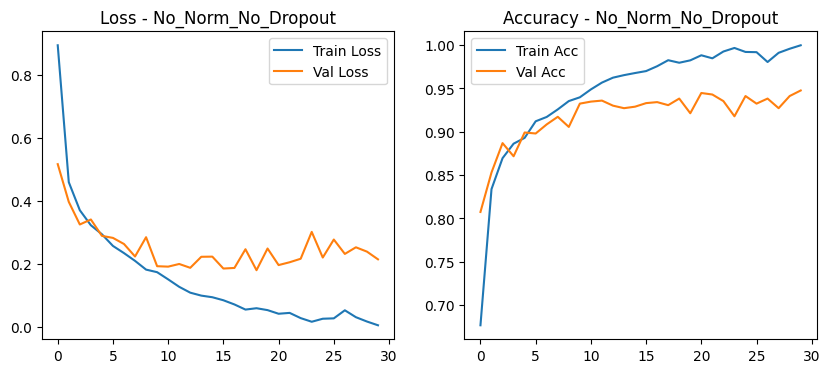

Test Accuracy: 0.9442


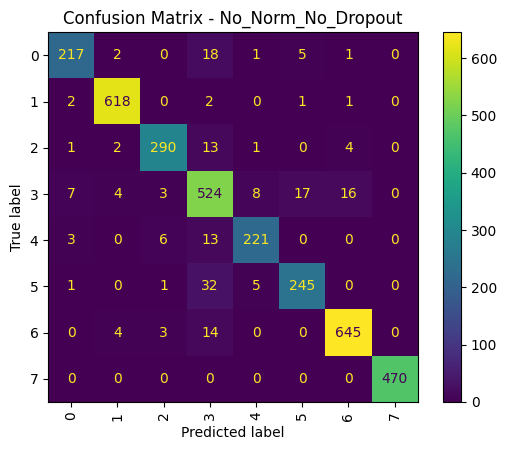


 Experiment: Batch_Norm
Epoch 1/30 - Train Acc: 0.8128, Val Acc: 0.8727
Epoch 2/30 - Train Acc: 0.8982, Val Acc: 0.8960
Epoch 3/30 - Train Acc: 0.9210, Val Acc: 0.9235
Epoch 4/30 - Train Acc: 0.9353, Val Acc: 0.9340
Epoch 5/30 - Train Acc: 0.9527, Val Acc: 0.9363
Epoch 6/30 - Train Acc: 0.9671, Val Acc: 0.9194
Epoch 7/30 - Train Acc: 0.9735, Val Acc: 0.9171
Epoch 8/30 - Train Acc: 0.9833, Val Acc: 0.9287
Epoch 9/30 - Train Acc: 0.9846, Val Acc: 0.9433
Epoch 10/30 - Train Acc: 0.9918, Val Acc: 0.9410
Epoch 11/30 - Train Acc: 0.9944, Val Acc: 0.9445
Epoch 12/30 - Train Acc: 0.9980, Val Acc: 0.9439
Epoch 13/30 - Train Acc: 0.9985, Val Acc: 0.9206
Epoch 14/30 - Train Acc: 0.9981, Val Acc: 0.9410
Epoch 15/30 - Train Acc: 0.9986, Val Acc: 0.9340
Epoch 16/30 - Train Acc: 0.9977, Val Acc: 0.9305
Epoch 17/30 - Train Acc: 0.9991, Val Acc: 0.9258
Epoch 18/30 - Train Acc: 0.9996, Val Acc: 0.9147
Epoch 19/30 - Train Acc: 0.9824, Val Acc: 0.9083
Epoch 20/30 - Train Acc: 0.9900, Val Acc: 0.9457
Epoc

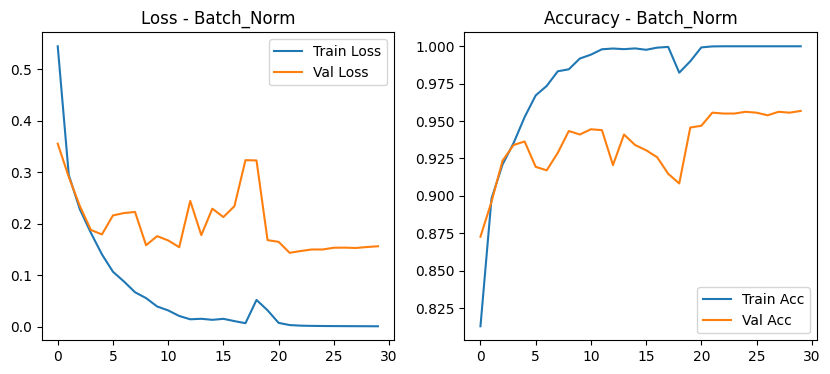

Test Accuracy: 0.9503


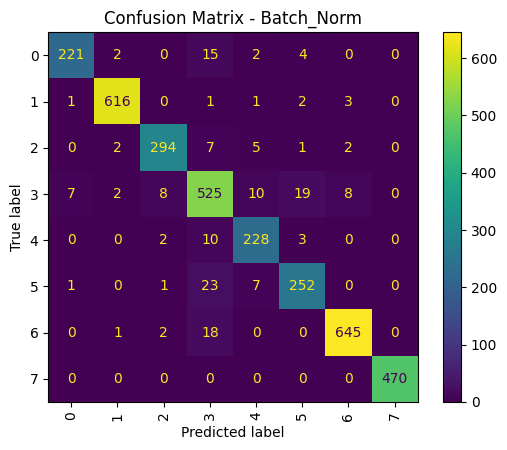


 Experiment: Dropout_0.2
Epoch 1/30 - Train Acc: 0.7942, Val Acc: 0.8791
Epoch 2/30 - Train Acc: 0.8877, Val Acc: 0.8814
Epoch 3/30 - Train Acc: 0.9130, Val Acc: 0.8919
Epoch 4/30 - Train Acc: 0.9307, Val Acc: 0.9001
Epoch 5/30 - Train Acc: 0.9403, Val Acc: 0.9118
Epoch 6/30 - Train Acc: 0.9498, Val Acc: 0.9229
Epoch 7/30 - Train Acc: 0.9533, Val Acc: 0.9445
Epoch 8/30 - Train Acc: 0.9615, Val Acc: 0.9509
Epoch 9/30 - Train Acc: 0.9653, Val Acc: 0.9153
Epoch 10/30 - Train Acc: 0.9705, Val Acc: 0.9498
Epoch 11/30 - Train Acc: 0.9737, Val Acc: 0.9112
Epoch 12/30 - Train Acc: 0.9748, Val Acc: 0.9241
Epoch 13/30 - Train Acc: 0.9806, Val Acc: 0.9492
Epoch 14/30 - Train Acc: 0.9823, Val Acc: 0.9468
Epoch 15/30 - Train Acc: 0.9859, Val Acc: 0.9492
Epoch 16/30 - Train Acc: 0.9868, Val Acc: 0.9217
Epoch 17/30 - Train Acc: 0.9878, Val Acc: 0.9381
Epoch 18/30 - Train Acc: 0.9887, Val Acc: 0.9217
Epoch 19/30 - Train Acc: 0.9899, Val Acc: 0.9439
Epoch 20/30 - Train Acc: 0.9907, Val Acc: 0.9328
Epo

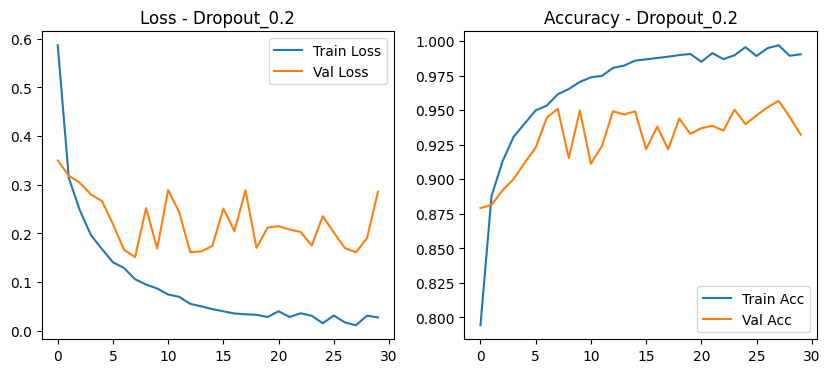

Test Accuracy: 0.9161


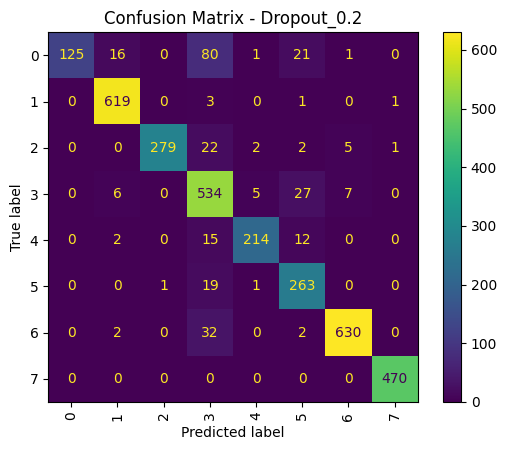


 Experiment: Dropout_0.5
Epoch 1/30 - Train Acc: 0.7777, Val Acc: 0.8592
Epoch 2/30 - Train Acc: 0.8727, Val Acc: 0.8978
Epoch 3/30 - Train Acc: 0.8977, Val Acc: 0.8861
Epoch 4/30 - Train Acc: 0.9093, Val Acc: 0.9211
Epoch 5/30 - Train Acc: 0.9178, Val Acc: 0.9322
Epoch 6/30 - Train Acc: 0.9343, Val Acc: 0.9229
Epoch 7/30 - Train Acc: 0.9319, Val Acc: 0.9457
Epoch 8/30 - Train Acc: 0.9372, Val Acc: 0.9270
Epoch 9/30 - Train Acc: 0.9450, Val Acc: 0.9398
Epoch 10/30 - Train Acc: 0.9500, Val Acc: 0.9393
Epoch 11/30 - Train Acc: 0.9509, Val Acc: 0.9439
Epoch 12/30 - Train Acc: 0.9548, Val Acc: 0.9474
Epoch 13/30 - Train Acc: 0.9596, Val Acc: 0.9498
Epoch 14/30 - Train Acc: 0.9638, Val Acc: 0.9100
Epoch 15/30 - Train Acc: 0.9647, Val Acc: 0.9515
Epoch 16/30 - Train Acc: 0.9663, Val Acc: 0.9515
Epoch 17/30 - Train Acc: 0.9705, Val Acc: 0.9603
Epoch 18/30 - Train Acc: 0.9701, Val Acc: 0.9357
Epoch 19/30 - Train Acc: 0.9680, Val Acc: 0.9550
Epoch 20/30 - Train Acc: 0.9759, Val Acc: 0.9492
Epo

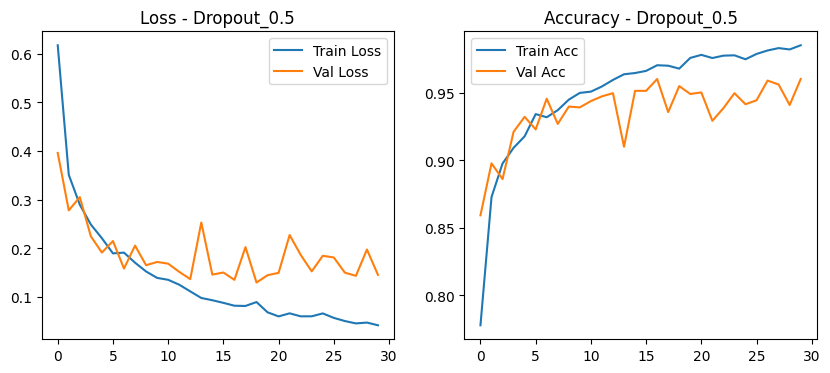

Test Accuracy: 0.9483


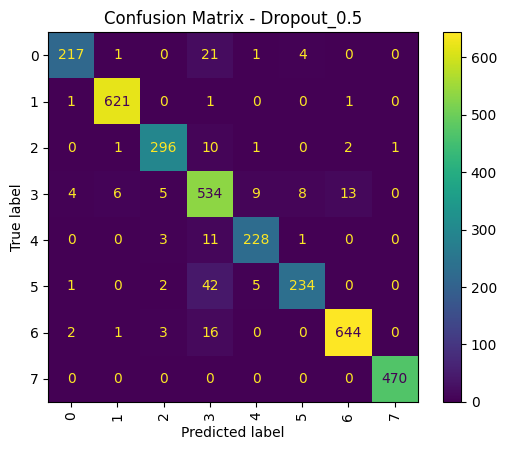


 Experiment: Dropout_0.7
Epoch 1/30 - Train Acc: 0.7376, Val Acc: 0.8294
Epoch 2/30 - Train Acc: 0.8489, Val Acc: 0.8785
Epoch 3/30 - Train Acc: 0.8696, Val Acc: 0.9095
Epoch 4/30 - Train Acc: 0.8826, Val Acc: 0.9136
Epoch 5/30 - Train Acc: 0.8986, Val Acc: 0.9223
Epoch 6/30 - Train Acc: 0.9033, Val Acc: 0.9194
Epoch 7/30 - Train Acc: 0.9098, Val Acc: 0.9381
Epoch 8/30 - Train Acc: 0.9166, Val Acc: 0.9357
Epoch 9/30 - Train Acc: 0.9211, Val Acc: 0.8896
Epoch 10/30 - Train Acc: 0.9234, Val Acc: 0.9328
Epoch 11/30 - Train Acc: 0.9323, Val Acc: 0.9463
Epoch 12/30 - Train Acc: 0.9345, Val Acc: 0.9515
Epoch 13/30 - Train Acc: 0.9378, Val Acc: 0.9480
Epoch 14/30 - Train Acc: 0.9406, Val Acc: 0.9375
Epoch 15/30 - Train Acc: 0.9391, Val Acc: 0.9468
Epoch 16/30 - Train Acc: 0.9462, Val Acc: 0.9433
Epoch 17/30 - Train Acc: 0.9466, Val Acc: 0.9468
Epoch 18/30 - Train Acc: 0.9494, Val Acc: 0.9445
Epoch 19/30 - Train Acc: 0.9528, Val Acc: 0.9480
Epoch 20/30 - Train Acc: 0.9534, Val Acc: 0.9504
Epo

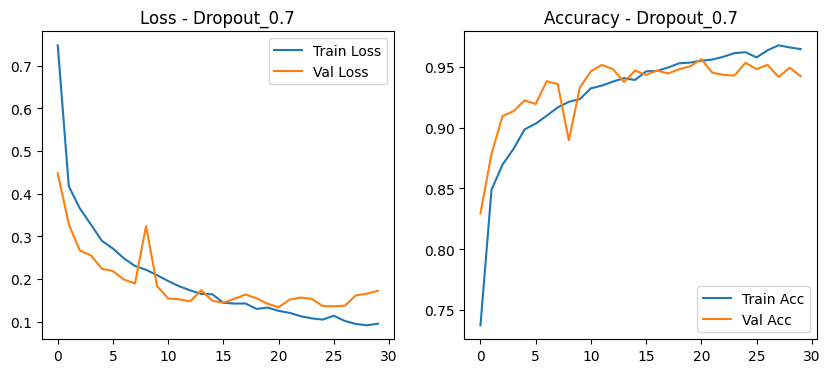

Test Accuracy: 0.9369


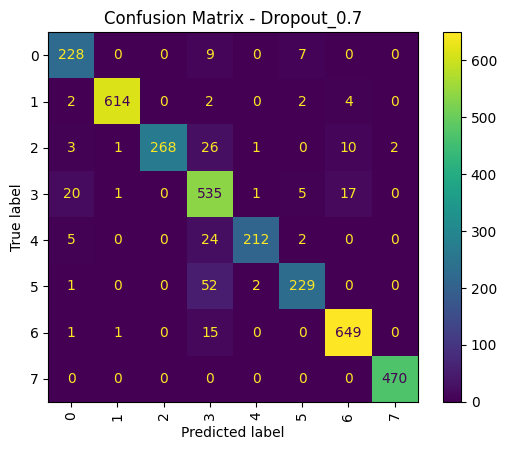


 Experiment: Weight_Decay_1e-4
Epoch 1/30 - Train Acc: 0.7770, Val Acc: 0.8919
Epoch 2/30 - Train Acc: 0.8664, Val Acc: 0.9019
Epoch 3/30 - Train Acc: 0.8900, Val Acc: 0.9153
Epoch 4/30 - Train Acc: 0.9154, Val Acc: 0.9328
Epoch 5/30 - Train Acc: 0.9220, Val Acc: 0.9317
Epoch 6/30 - Train Acc: 0.9230, Val Acc: 0.9322
Epoch 7/30 - Train Acc: 0.9336, Val Acc: 0.9480
Epoch 8/30 - Train Acc: 0.9403, Val Acc: 0.9211
Epoch 9/30 - Train Acc: 0.9449, Val Acc: 0.9498
Epoch 10/30 - Train Acc: 0.9498, Val Acc: 0.9428
Epoch 11/30 - Train Acc: 0.9575, Val Acc: 0.9404
Epoch 12/30 - Train Acc: 0.9566, Val Acc: 0.9445
Epoch 13/30 - Train Acc: 0.9592, Val Acc: 0.9486
Epoch 14/30 - Train Acc: 0.9637, Val Acc: 0.9486
Epoch 15/30 - Train Acc: 0.9674, Val Acc: 0.9486
Epoch 16/30 - Train Acc: 0.9675, Val Acc: 0.9515
Epoch 17/30 - Train Acc: 0.9676, Val Acc: 0.9381
Epoch 18/30 - Train Acc: 0.9686, Val Acc: 0.9498
Epoch 19/30 - Train Acc: 0.9725, Val Acc: 0.9492
Epoch 20/30 - Train Acc: 0.9734, Val Acc: 0.96

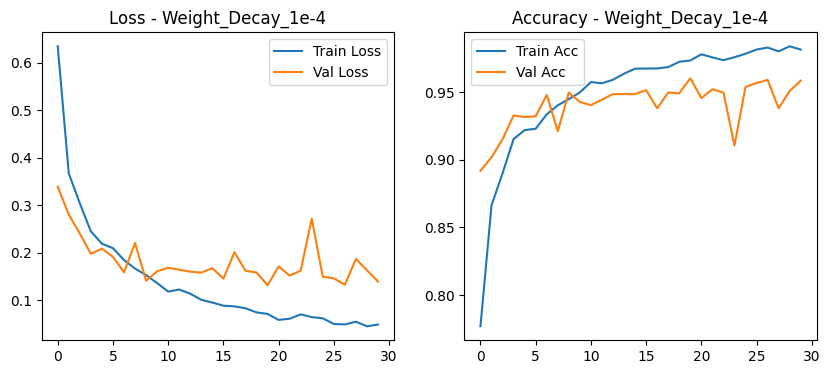

Test Accuracy: 0.9506


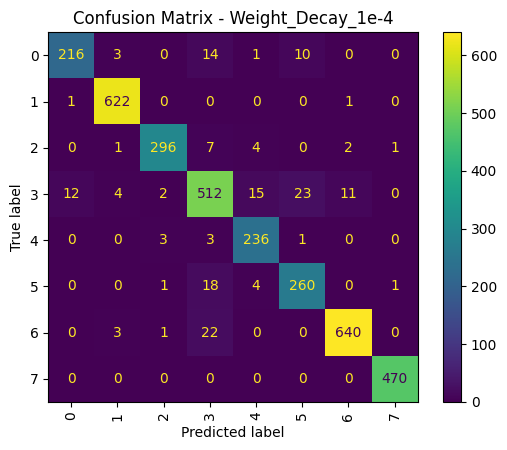


 Experiment: Weight_Decay_1e-3
Epoch 1/30 - Train Acc: 0.7701, Val Acc: 0.8651
Epoch 2/30 - Train Acc: 0.8686, Val Acc: 0.8791
Epoch 3/30 - Train Acc: 0.8926, Val Acc: 0.8803
Epoch 4/30 - Train Acc: 0.9062, Val Acc: 0.9200
Epoch 5/30 - Train Acc: 0.9166, Val Acc: 0.9270
Epoch 6/30 - Train Acc: 0.9224, Val Acc: 0.9363
Epoch 7/30 - Train Acc: 0.9329, Val Acc: 0.9235
Epoch 8/30 - Train Acc: 0.9355, Val Acc: 0.9328
Epoch 9/30 - Train Acc: 0.9414, Val Acc: 0.9504
Epoch 10/30 - Train Acc: 0.9483, Val Acc: 0.9468
Epoch 11/30 - Train Acc: 0.9484, Val Acc: 0.9147
Epoch 12/30 - Train Acc: 0.9526, Val Acc: 0.9317
Epoch 13/30 - Train Acc: 0.9548, Val Acc: 0.9299
Epoch 14/30 - Train Acc: 0.9589, Val Acc: 0.9293
Epoch 15/30 - Train Acc: 0.9562, Val Acc: 0.9451
Epoch 16/30 - Train Acc: 0.9629, Val Acc: 0.9568
Epoch 17/30 - Train Acc: 0.9679, Val Acc: 0.9404
Epoch 18/30 - Train Acc: 0.9647, Val Acc: 0.9393
Epoch 19/30 - Train Acc: 0.9682, Val Acc: 0.9445
Epoch 20/30 - Train Acc: 0.9674, Val Acc: 0.95

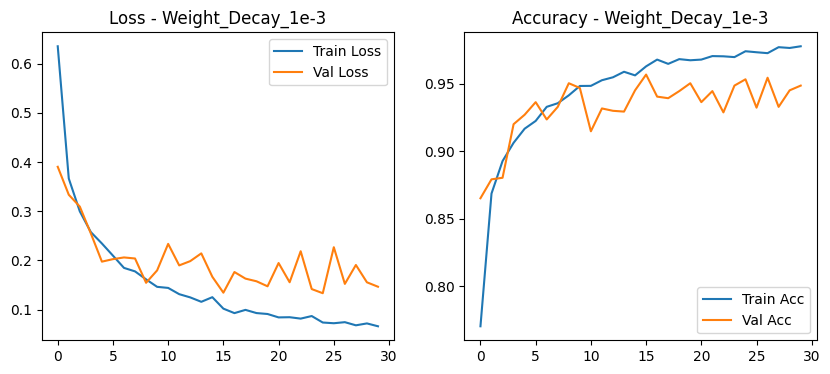

Test Accuracy: 0.9424


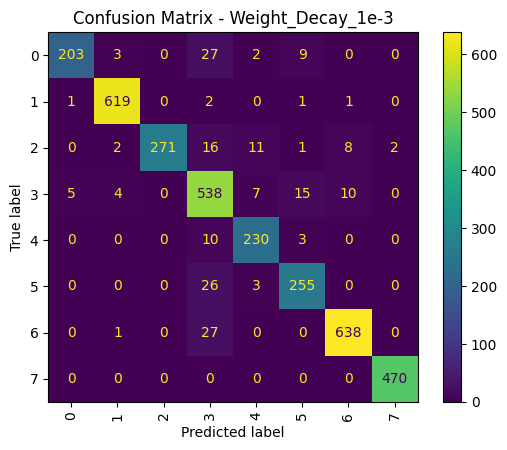


 Experiment: Weight_Decay_1e-2
Epoch 1/30 - Train Acc: 0.7766, Val Acc: 0.8277
Epoch 2/30 - Train Acc: 0.8650, Val Acc: 0.8966
Epoch 3/30 - Train Acc: 0.8864, Val Acc: 0.8452
Epoch 4/30 - Train Acc: 0.9043, Val Acc: 0.9188
Epoch 5/30 - Train Acc: 0.9119, Val Acc: 0.7775
Epoch 6/30 - Train Acc: 0.9170, Val Acc: 0.9404
Epoch 7/30 - Train Acc: 0.9205, Val Acc: 0.9229
Epoch 8/30 - Train Acc: 0.9237, Val Acc: 0.9334
Epoch 9/30 - Train Acc: 0.9273, Val Acc: 0.9282
Epoch 10/30 - Train Acc: 0.9339, Val Acc: 0.9246
Epoch 11/30 - Train Acc: 0.9342, Val Acc: 0.9398
Epoch 12/30 - Train Acc: 0.9339, Val Acc: 0.9171
Epoch 13/30 - Train Acc: 0.9324, Val Acc: 0.9095
Epoch 14/30 - Train Acc: 0.9339, Val Acc: 0.9416
Epoch 15/30 - Train Acc: 0.9363, Val Acc: 0.9305
Epoch 16/30 - Train Acc: 0.9388, Val Acc: 0.9206
Epoch 17/30 - Train Acc: 0.9438, Val Acc: 0.9200
Epoch 18/30 - Train Acc: 0.9386, Val Acc: 0.9112
Epoch 19/30 - Train Acc: 0.9420, Val Acc: 0.9147
Epoch 20/30 - Train Acc: 0.9456, Val Acc: 0.88

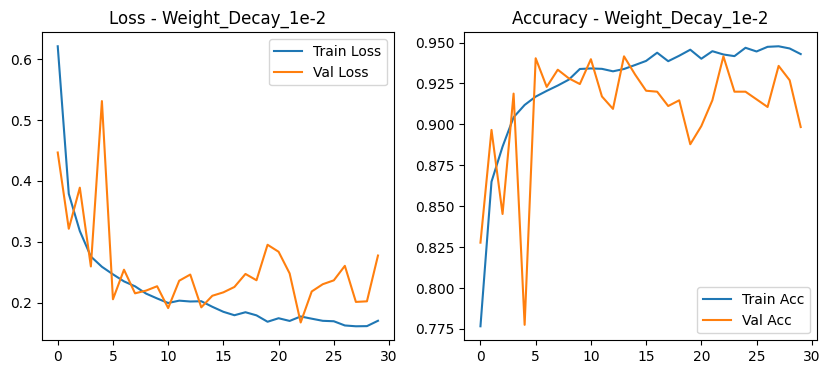

Test Accuracy: 0.8869


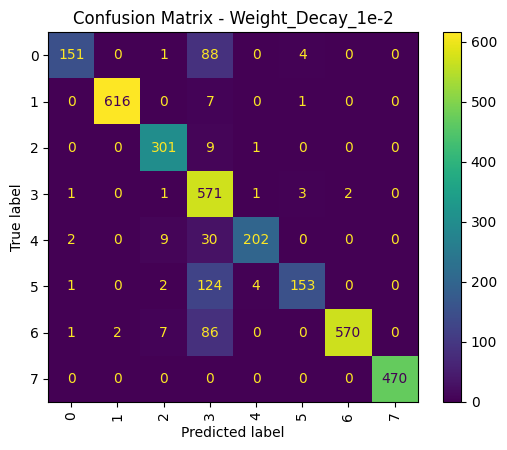

In [ ]:
class MedicalCNN(nn.Module):
    def __init__(self, num_classes, num_blocks=3, norm_type=None, dropout_prob=0.0):
        super(MedicalCNN, self).__init__()
        layers = []
        in_channels = 3  # because the image is RGB
        filters = [32, 64, 128, 256] #doubling in each layer, as requested my computing power could support an extra layer

        for i in range(num_blocks):
            layers.append(nn.Conv2d(in_channels, filters[i], kernel_size=3, padding=1)) #kernel 3x3
            if norm_type == 'batch':  # if batch normalization is selected, we normalize
                layers.append(nn.BatchNorm2d(filters[i]))
            layers.append(nn.ReLU()) #ReLU activation function
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2)) #max pooling in a square 2x2
            in_channels = filters[i]

        self.features = nn.Sequential(*layers)

        final_dim = 28 // (2**num_blocks) #we cut in 'half' in each layer (quarter if we consider the total square image)
        fc_input_size = filters[num_blocks-1] * final_dim * final_dim

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_prob),
            nn.Linear(fc_input_size, num_classes) #the connected layer has as many neurons as the number of classes
        )

# forward pass
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


def train_model(model, train_loader, val_loader, device, epochs=30, lr=1e-3, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss() #categorical cross entropy loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay) # we were asked to use Adam optimizer

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []} # we will later save here the metrics

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += (outputs.argmax(1) == targets).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                val_correct += (outputs.argmax(1) == targets).sum().item()

        # Save history
        history['train_loss'].append(train_loss/len(train_loader))
        history['val_loss'].append(val_loss/len(val_loader))
        history['train_acc'].append(train_correct/len(train_dataset))
        history['val_acc'].append(val_correct/len(val_dataset))

        print(f"Epoch {epoch+1}/{epochs} - Train Acc: {history['train_acc'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")

    return history

# multiple experiments playing with the parameters we were either asked to or we are free to play with
experiments = [
    {'name':'No_Norm_No_Dropout','norm_type':None, 'dropout':0.0, 'weight_decay':0.0, 'lr':1e-3},
    {'name':'Batch_Norm','norm_type':'batch', 'dropout':0.0, 'weight_decay':0.0, 'lr':5e-4},
    {'name':'Dropout_0.2','norm_type':'batch', 'dropout':0.2, 'weight_decay':0.0, 'lr':1e-3},
    {'name':'Dropout_0.5','norm_type':'batch', 'dropout':0.5, 'weight_decay':0.0, 'lr':1e-3},
    {'name':'Dropout_0.7','norm_type':'batch', 'dropout':0.7, 'weight_decay':0.0, 'lr':1e-3},
    {'name':'Weight_Decay_1e-4','norm_type':'batch', 'dropout':0.5, 'weight_decay':1e-4, 'lr':1e-3},
    {'name':'Weight_Decay_1e-3','norm_type':'batch', 'dropout':0.5, 'weight_decay':1e-3, 'lr':1e-3},
    {'name':'Weight_Decay_1e-2','norm_type':'batch', 'dropout':0.5, 'weight_decay':1e-2, 'lr':1e-3},
]

results = {}

for exp in experiments:
    print(f"\n Experiment: {exp['name']}")
    model = MedicalCNN(num_classes=num_classes, norm_type=exp['norm_type'], dropout_prob=exp['dropout']).to(device)
    history = train_model(model, train_loader, val_loader, device, epochs=30, lr=exp['lr'], weight_decay=exp['weight_decay'])
    results[exp['name']] = {'history':history, 'model':model}

    # plotting the results
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f"Loss - {exp['name']}")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f"Accuracy - {exp['name']}")
    plt.legend()
    plt.show()

    # testing
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            outputs = model(inputs)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(outputs.argmax(1).cpu().numpy())

    test_acc = np.mean(np.array(y_true) == np.array(y_pred))
    print(f"Test Accuracy: {test_acc:.4f}")

    # also showing the confusion matrices
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))

    disp.plot(xticks_rotation='vertical')
    plt.title(f"Confusion Matrix - {exp['name']}")
    plt.show()


-------------------------------------------------------------------


In [ ]:
import torchvision.models as models

# resizing into 64x64 to fit the pretrained model of resnet18
transform_transfer = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # !pretrained models expect input images normalized using ImageNet statistics and these are the values it expects
])

train_dataset_tf = DataClass(split='train', transform=transform_transfer, download=True)
val_dataset_tf = DataClass(split='val', transform=transform_transfer, download=True)

train_loader_tf = data.DataLoader(dataset=train_dataset_tf, batch_size=64, shuffle=True)
val_loader_tf = data.DataLoader(dataset=val_dataset_tf, batch_size=64, shuffle=False)

In [ ]:
# loading resenet18 which is a pretrained model on ImageNet
resnet = models.resnet18(pretrained=True)

for param in resnet.parameters():
    param.requires_grad = False   #we 'freeze' the weights. the model has already learned some stuff from imagenet and now works as feature extractor

num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 8) # we change the fully connected layer into 8 because this is the number of our different classes

resnet = resnet.to(device)
optimizer_fe = optim.Adam(resnet.fc.parameters(), lr=1e-3)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


In [ ]:
def run_transfer_experiment(model, loader_train, loader_val, optimizer, epochs, title):
    criterion = nn.CrossEntropyLoss()

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    print(f"\n{title}")
    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        for inputs, targets in loader_train:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

        train_acc = 100. * correct / total
        train_loss /= len(loader_train)


        model.eval()
        val_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for inputs, targets in loader_val:
                inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                val_loss += loss.item()
                preds = outputs.argmax(1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)

        val_acc = 100. * correct / total
        val_loss /= len(loader_val)


        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.3f}, Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.3f}, Val Acc: {val_acc:.2f}%"
        )

    return history


In [ ]:
def plot_history(history, title):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(14,6))

    # loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss')
    plt.plot(epochs, history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    # accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Acc')
    plt.plot(epochs, history['val_acc'], label='Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()



Feature Extraction
Epoch [1/20] | Train Loss: 1.101, Train Acc: 62.88% | Val Loss: 0.802, Val Acc: 74.07%
Epoch [2/20] | Train Loss: 0.764, Train Acc: 74.55% | Val Loss: 0.707, Val Acc: 76.46%
Epoch [3/20] | Train Loss: 0.698, Train Acc: 76.19% | Val Loss: 0.685, Val Acc: 77.51%
Epoch [4/20] | Train Loss: 0.669, Train Acc: 76.98% | Val Loss: 0.677, Val Acc: 76.87%
Epoch [5/20] | Train Loss: 0.646, Train Acc: 77.85% | Val Loss: 0.651, Val Acc: 78.27%
Epoch [6/20] | Train Loss: 0.626, Train Acc: 78.74% | Val Loss: 0.655, Val Acc: 77.04%
Epoch [7/20] | Train Loss: 0.618, Train Acc: 78.40% | Val Loss: 0.648, Val Acc: 77.39%
Epoch [8/20] | Train Loss: 0.611, Train Acc: 79.10% | Val Loss: 0.646, Val Acc: 78.39%
Epoch [9/20] | Train Loss: 0.601, Train Acc: 79.24% | Val Loss: 0.636, Val Acc: 78.04%
Epoch [10/20] | Train Loss: 0.607, Train Acc: 78.81% | Val Loss: 0.655, Val Acc: 77.22%
Epoch [11/20] | Train Loss: 0.594, Train Acc: 79.33% | Val Loss: 0.676, Val Acc: 77.22%
Epoch [12/20] | Train

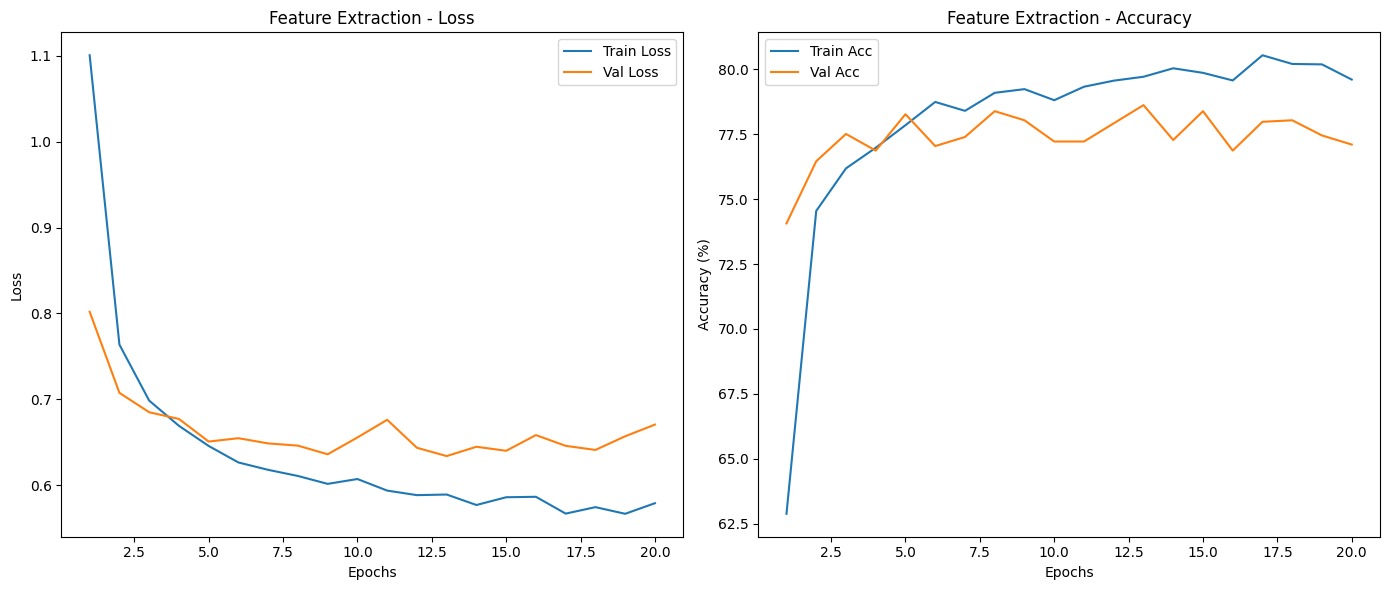

In [ ]:
resnet_fe = models.resnet18(pretrained=True)

for param in resnet_fe.parameters():
    param.requires_grad = False

resnet_fe.fc = nn.Linear(resnet_fe.fc.in_features, 8)
resnet_fe = resnet_fe.to(device)

optimizer_fe = optim.Adam(resnet_fe.fc.parameters(), lr=1e-3)

history_fe = run_transfer_experiment(
    resnet_fe,
    train_loader_tf,
    val_loader_tf,
    optimizer_fe,
    epochs=20,
    title="Feature Extraction"
)

plot_history(history_fe, "Feature Extraction")



Fine-Tuning
Epoch [1/15] | Train Loss: 0.475, Train Acc: 83.77% | Val Loss: 0.239, Val Acc: 91.71%
Epoch [2/15] | Train Loss: 0.170, Train Acc: 94.06% | Val Loss: 0.215, Val Acc: 92.70%
Epoch [3/15] | Train Loss: 0.096, Train Acc: 96.80% | Val Loss: 0.238, Val Acc: 92.46%
Epoch [4/15] | Train Loss: 0.057, Train Acc: 98.00% | Val Loss: 0.211, Val Acc: 92.76%
Epoch [5/15] | Train Loss: 0.052, Train Acc: 98.19% | Val Loss: 0.260, Val Acc: 92.87%
Epoch [6/15] | Train Loss: 0.038, Train Acc: 98.74% | Val Loss: 0.276, Val Acc: 92.23%
Epoch [7/15] | Train Loss: 0.036, Train Acc: 98.87% | Val Loss: 0.288, Val Acc: 91.94%
Epoch [8/15] | Train Loss: 0.034, Train Acc: 98.88% | Val Loss: 0.232, Val Acc: 93.46%
Epoch [9/15] | Train Loss: 0.026, Train Acc: 99.11% | Val Loss: 0.238, Val Acc: 93.63%
Epoch [10/15] | Train Loss: 0.032, Train Acc: 98.98% | Val Loss: 0.280, Val Acc: 93.05%
Epoch [11/15] | Train Loss: 0.024, Train Acc: 99.16% | Val Loss: 0.274, Val Acc: 92.11%
Epoch [12/15] | Train Loss: 

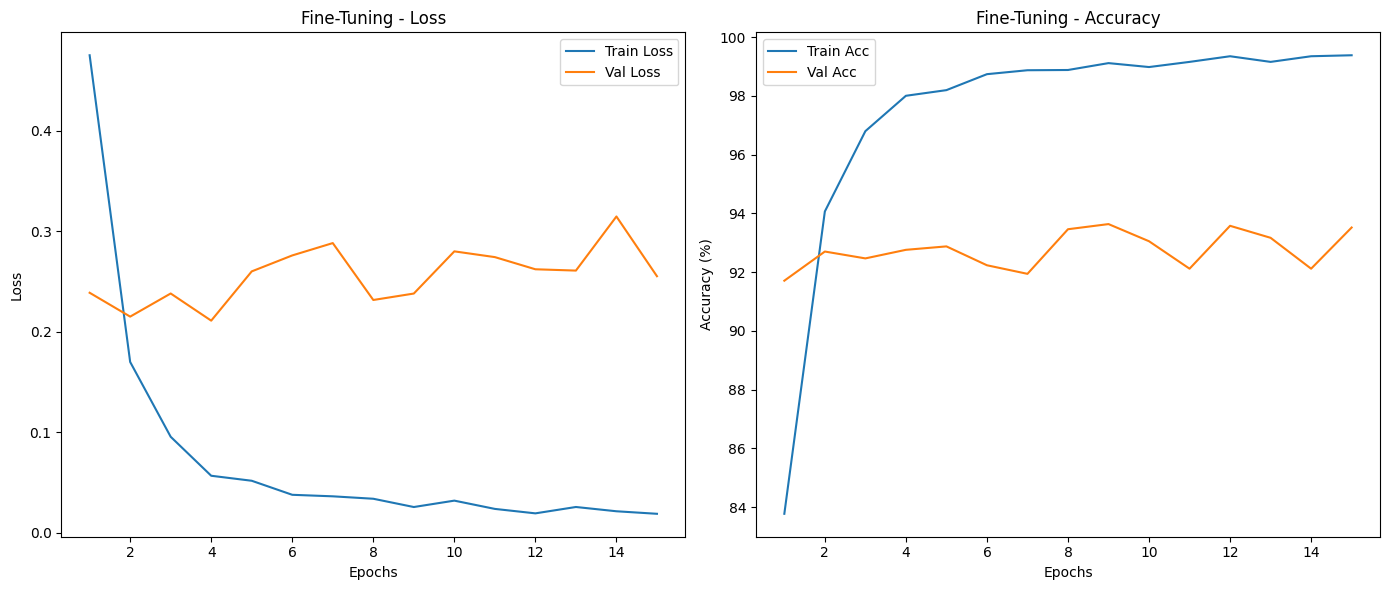

In [ ]:
resnet_ft = models.resnet18(pretrained=True)

for param in resnet_ft.parameters():
    param.requires_grad = False

resnet_ft.fc = nn.Linear(resnet_ft.fc.in_features, 8)
resnet_ft = resnet_ft.to(device)

for param in resnet_ft.layer3.parameters():
    param.requires_grad = True
for param in resnet_ft.layer4.parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_ft.parameters()),
    lr=1e-4
)

train_loader_ft = data.DataLoader(
    dataset=train_dataset_tf,
    batch_size=32,
    shuffle=True
)

history_ft = run_transfer_experiment(
    resnet_ft,
    train_loader_ft,
    val_loader_tf,
    optimizer_ft,
    epochs=15,
    title="Fine-Tuning"
)

plot_history(history_ft, "Fine-Tuning")


In [ ]:
def evaluate_model(model, loader, class_names, title):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            outputs = model(inputs)
            preds = outputs.argmax(1)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"\n--- {title} ---")
    print(f"Balanced Accuracy: {bal_acc:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))

    plt.figure(figsize=(10,8))
    disp.plot(cmap="viridis", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    return bal_acc


In [ ]:
test_dataset_tf = DataClass(
    split='test',
    transform=transform_transfer,
    download=True
)

test_loader_tf = data.DataLoader(
    dataset=test_dataset_tf,
    batch_size=32,
    shuffle=False
)




--- Feature Extraction ---
Balanced Accuracy: 0.6860
                                                                     precision    recall  f1-score   support

                                                           basophil       0.70      0.43      0.53       244
                                                         eosinophil       0.94      0.94      0.94       624
                                                       erythroblast       0.78      0.61      0.68       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.53      0.82      0.64       579
                                                         lymphocyte       0.63      0.62      0.62       243
                                                           monocyte       0.72      0.33      0.45       284
                                                         neutrophil       0.84      0.80      0.82       666
                                                           platelet      

<Figure size 1000x800 with 0 Axes>

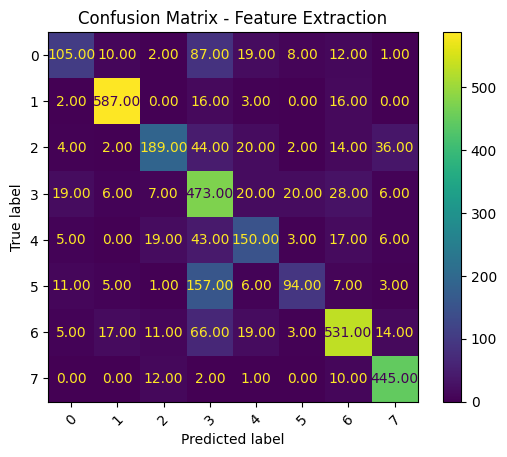


--- Fine-Tuning ---
Balanced Accuracy: 0.9306
                                                                     precision    recall  f1-score   support

                                                           basophil       0.91      0.90      0.91       244
                                                         eosinophil       0.99      0.99      0.99       624
                                                       erythroblast       0.98      0.93      0.95       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.86      0.85      0.85       579
                                                         lymphocyte       0.97      0.93      0.95       243
                                                           monocyte       0.84      0.87      0.85       284
                                                         neutrophil       0.95      0.98      0.96       666
                                                           platelet       1.00  

<Figure size 1000x800 with 0 Axes>

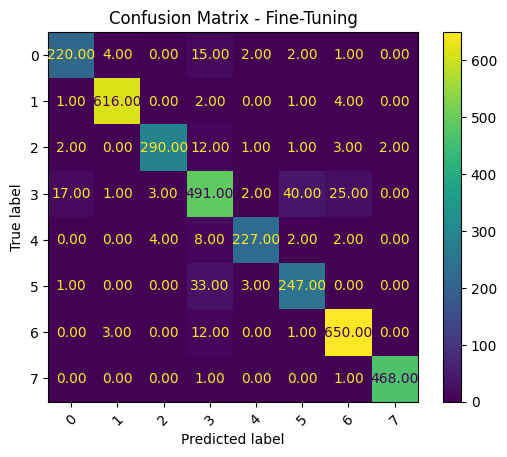

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score


class_names = [str(v) for v in info['label'].values()]

bal_acc_fe = evaluate_model(
    resnet_fe,
    test_loader_tf,
    class_names,
    title="Feature Extraction"
)

bal_acc_ft = evaluate_model(
    resnet_ft,
    test_loader_tf,
    class_names,
    title="Fine-Tuning"
)


----------------------------------------------------

The procedure is almost the same we just change from the pretrained resnet to a transformer

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils import data
import torchvision.transforms as transforms
import timm
import matplotlib.pyplot as plt
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]


--- ViT Feature Extraction (Head Only) ---
Epoch 1/10 | Train Loss: 1.0585, Train Acc: 65.42% | Val Loss: 0.7616, Val Acc: 75.29%
Epoch 2/10 | Train Loss: 0.6661, Train Acc: 78.30% | Val Loss: 0.6181, Val Acc: 80.67%
Epoch 3/10 | Train Loss: 0.5760, Train Acc: 80.74% | Val Loss: 0.5713, Val Acc: 81.37%
Epoch 4/10 | Train Loss: 0.5310, Train Acc: 82.26% | Val Loss: 0.5300, Val Acc: 82.01%
Epoch 5/10 | Train Loss: 0.5042, Train Acc: 83.13% | Val Loss: 0.5138, Val Acc: 82.42%
Epoch 6/10 | Train Loss: 0.4822, Train Acc: 83.52% | Val Loss: 0.5017, Val Acc: 82.94%
Epoch 7/10 | Train Loss: 0.4660, Train Acc: 84.01% | Val Loss: 0.4933, Val Acc: 83.18%
Epoch 8/10 | Train Loss: 0.4531, Train Acc: 84.57% | Val Loss: 0.4822, Val Acc: 83.88%
Epoch 9/10 | Train Loss: 0.4427, Train Acc: 84.94% | Val Loss: 0.4677, Val Acc: 83.53%
Epoch 10/10 | Train Loss: 0.4326, Train Acc: 85.18% | Val Loss: 0.4647, Val Acc: 84.11%

--- ViT Fine-Tuning (Last 2 Blocks + Head) ---
Epoch 1/5 | Train Loss: 0.4140, Train

<Figure size 1000x800 with 0 Axes>

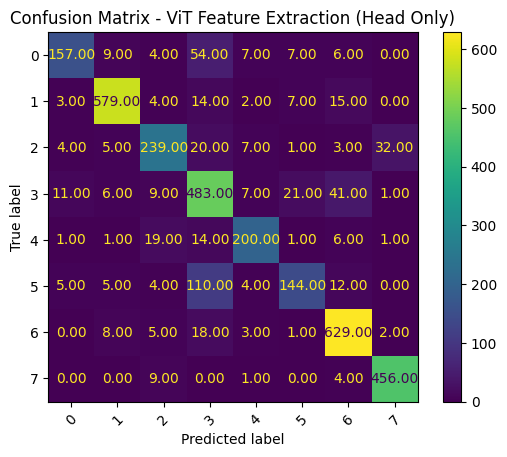


--- ViT Fine-Tuning (Last 2 Blocks + Head) ---
Balanced Accuracy: 0.8959
                                                                     precision    recall  f1-score   support

                                                           basophil       0.84      0.90      0.87       244
                                                         eosinophil       0.99      0.98      0.98       624
                                                       erythroblast       0.88      0.93      0.90       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.90      0.67      0.76       579
                                                         lymphocyte       0.97      0.81      0.88       243
                                                           monocyte       0.65      0.92      0.76       284
                                                         neutrophil       0.91      0.97      0.94       666
                                                     

<Figure size 1000x800 with 0 Axes>

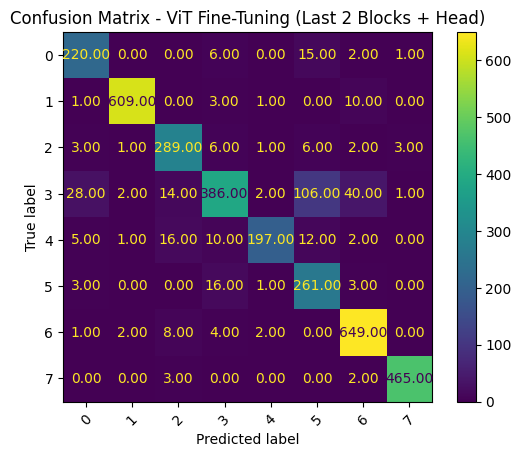

In [ ]:
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_vit = DataClass(split='train', transform=transform_vit, download=True)
val_dataset_vit   = DataClass(split='val', transform=transform_vit, download=True)
test_dataset_vit  = DataClass(split='test', transform=transform_vit, download=True)

train_loader_vit = data.DataLoader(train_dataset_vit, batch_size=32, shuffle=True)
val_loader_vit   = data.DataLoader(val_dataset_vit, batch_size=32, shuffle=False)
test_loader_vit  = data.DataLoader(test_dataset_vit, batch_size=32, shuffle=False)

class_names = [str(v) for v in info['label'].values()]

model_vit_fe = timm.create_model('deit_tiny_patch16_224', pretrained=True)
for param in model_vit_fe.parameters():
    param.requires_grad = False  # Freeze all layers

model_vit_fe.head = nn.Linear(model_vit_fe.head.in_features, 8)
model_vit_fe = model_vit_fe.to(device)

optimizer_fe = optim.Adam(model_vit_fe.head.parameters(), lr=1e-3)

def run_transfer_experiment(model, loader_train, loader_val, optimizer, epochs, title):
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n--- {title} ---")
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train = 0.0, 0
        total_train = 0
        for inputs, targets in loader_train:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct_train += (outputs.argmax(1) == targets).sum().item()
            total_train += targets.size(0)

        train_loss = running_loss / total_train
        train_acc = 100. * correct_train / total_train

        model.eval()
        running_val_loss, correct_val = 0.0, 0
        total_val = 0
        with torch.no_grad():
            for inputs, targets in loader_val:
                inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
                correct_val += (outputs.argmax(1) == targets).sum().item()
                total_val += targets.size(0)

        val_loss = running_val_loss / total_val
        val_acc = 100. * correct_val / total_val

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history


history_vit_fe = run_transfer_experiment(
    model_vit_fe,
    train_loader_vit,
    val_loader_vit,
    optimizer_fe,
    epochs=10,
    title="ViT Feature Extraction (Head Only)"
)


model_vit_ft = copy.deepcopy(model_vit_fe)

# unfreeze last 2 blocks
for param in model_vit_ft.blocks[-2:].parameters():
    param.requires_grad = True

optimizer_ft = optim.Adam(filter(lambda p: p.requires_grad, model_vit_ft.parameters()), lr=1e-4)
train_loader_ft = data.DataLoader(train_dataset_vit, batch_size=16, shuffle=True)

history_vit_ft = run_transfer_experiment(
    model_vit_ft,
    train_loader_ft,
    val_loader_vit,
    optimizer_ft,
    epochs=5,
    title="ViT Fine-Tuning (Last 2 Blocks + Head)"
)

def evaluate_model(model, loader, class_names, title="Evaluation"):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device).squeeze().long()
            outputs = model(inputs)
            preds = outputs.argmax(1)
            y_true.extend(targets.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    bal_acc = balanced_accuracy_score(y_true, y_pred)
    print(f"\n--- {title} ---")
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
    plt.figure(figsize=(10,8))
    disp.plot(cmap="viridis", xticks_rotation=45, values_format=".2f")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

    return bal_acc

bal_acc_fe = evaluate_model(model_vit_fe, test_loader_vit, class_names, title="ViT Feature Extraction (Head Only)")
bal_acc_ft = evaluate_model(model_vit_ft, test_loader_vit, class_names, title="ViT Fine-Tuning (Last 2 Blocks + Head)")


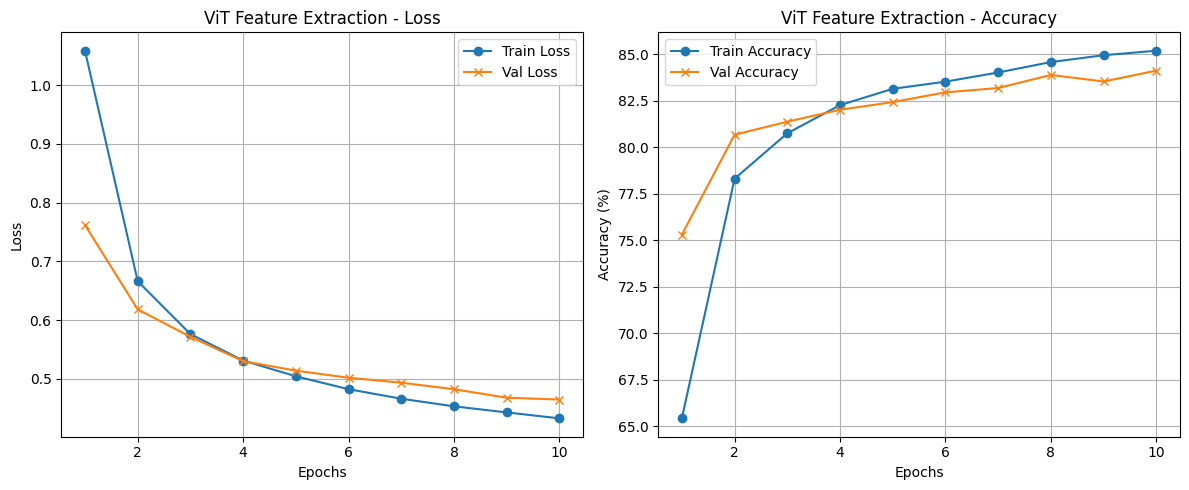

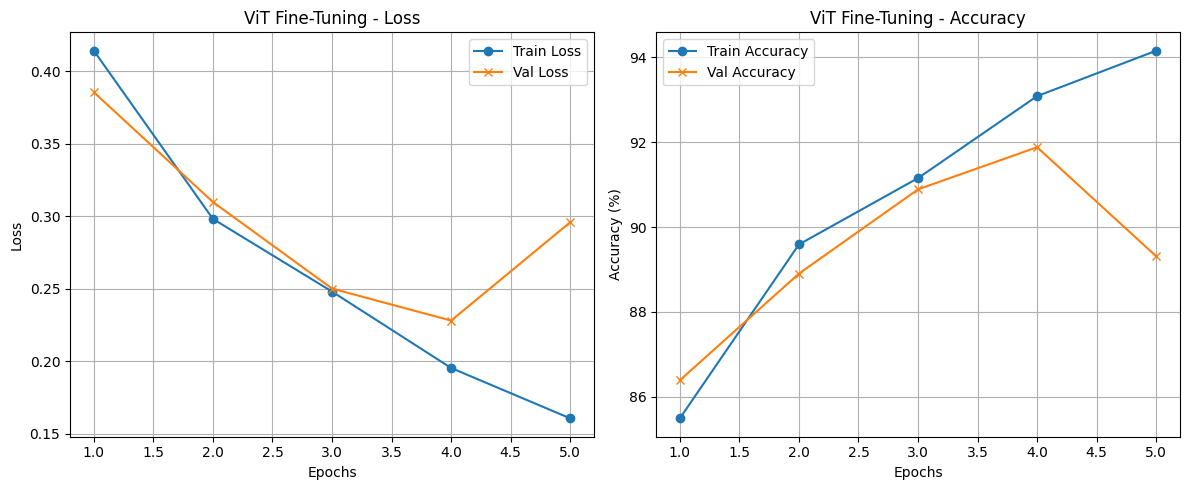

In [ ]:
import matplotlib.pyplot as plt

def plot_full_training_history(history, title="Training History"):

    epochs = range(1, len(history['train_loss'])+1)

    plt.figure(figsize=(12,5))

    # loss plot
    plt.subplot(1,2,1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='x')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.grid(True)

    # accuracy plot
    plt.subplot(1,2,2)
    plt.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o')
    plt.plot(epochs, history['val_acc'], label='Val Accuracy', marker='x')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.title(f'{title} - Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_full_training_history(history_vit_fe, title="ViT Feature Extraction")

plot_full_training_history(history_vit_ft, title="ViT Fine-Tuning")
